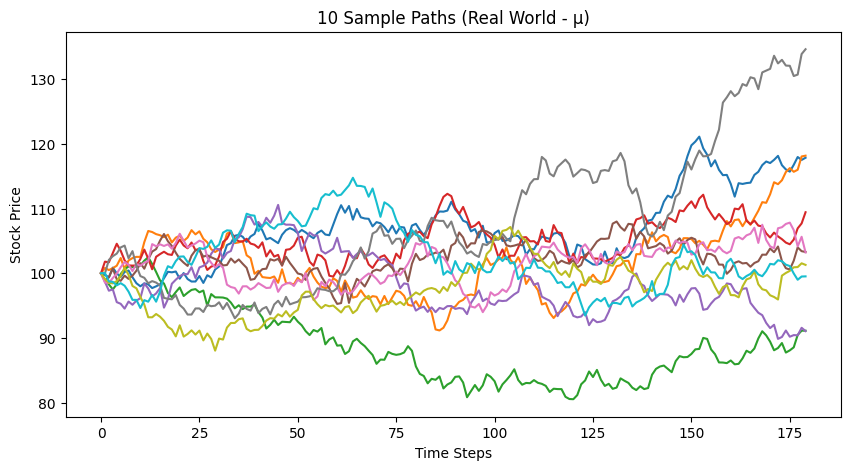

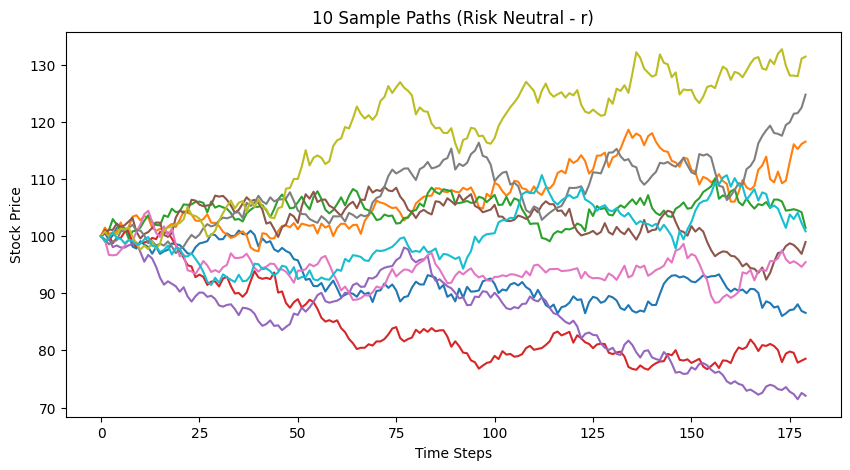

Asian Option Prices:

K = 90
 Call (MC) = 10.7667, Call (VR) = 11.3022
 Put  (MC) = 0.2485, Put  (VR) = 0.2735

K = 105
 Call (MC) = 1.5744, Call (VR) = 1.8550
 Put  (MC) = 5.5857, Put  (VR) = 5.5371

K = 110
 Call (MC) = 0.7244, Call (VR) = 0.6204
 Put  (MC) = 8.8435, Put  (VR) = 9.2315



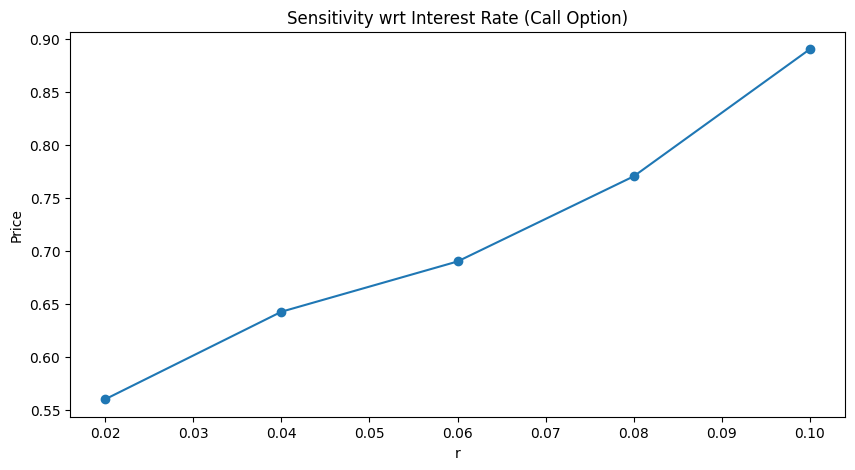

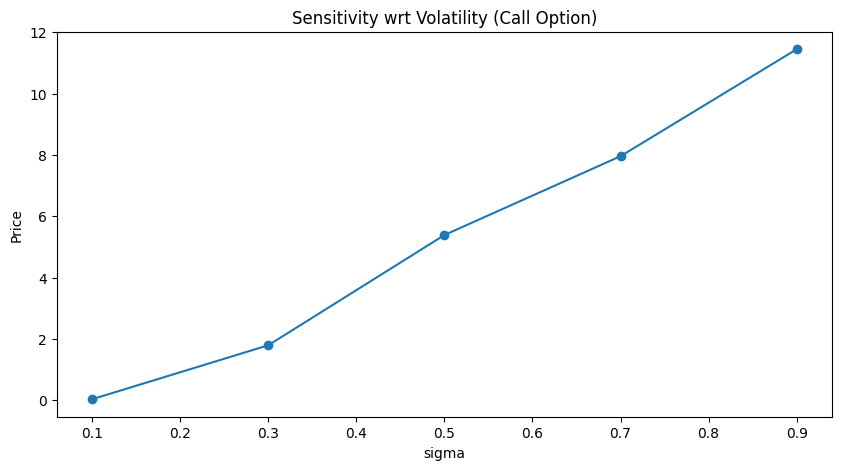

In [1]:


import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [10, 5]

# -------------------------------
# 1. GBM Stock Path Simulation
# -------------------------------
def getStockPath(S0, drift, sigma, T, n, varReduction=False):
    dt = T / n

    S_plus = np.zeros(n)
    S_plus[0] = S0

    if varReduction:
        S_minus = np.zeros(n)
        S_minus[0] = S0

    for i in range(1, n):
        Z = np.random.randn()
        dW = np.sqrt(dt) * Z

        S_plus[i] = S_plus[i-1] * np.exp((drift - 0.5 * sigma**2)*dt + sigma * dW)

        if varReduction:
            S_minus[i] = S_minus[i-1] * np.exp((drift - 0.5 * sigma**2)*dt - sigma * dW)

    if varReduction:
        return S_plus, S_minus
    else:
        return S_plus


# -------------------------------
# 2. Plot 10 sample paths
# -------------------------------
def plotSamplePaths(S0, mu, r, sigma, T, n):
    plt.title("10 Sample Paths (Real World - μ)")
    for _ in range(10):
        S = getStockPath(S0, mu, sigma, T, n)
        plt.plot(S)
    plt.xlabel("Time Steps")
    plt.ylabel("Stock Price")
    plt.show()

    plt.title("10 Sample Paths (Risk Neutral - r)")
    for _ in range(10):
        S = getStockPath(S0, r, sigma, T, n)
        plt.plot(S)
    plt.xlabel("Time Steps")
    plt.ylabel("Stock Price")
    plt.show()


# -------------------------------
# 3. Asian Option Pricing
# -------------------------------
def getAsianOptionPrice(S0, r, sigma, T, n, K, option_type="call", varReduction=False):

    numPaths = 500
    payoffs = []

    for _ in range(numPaths):
        if varReduction:
            S_plus, S_minus = getStockPath(S0, r, sigma, T, n, True)

            if option_type == "call":
                V_plus = max(np.mean(S_plus) - K, 0)
                V_minus = max(np.mean(S_minus) - K, 0)
            else:
                V_plus = max(K - np.mean(S_plus), 0)
                V_minus = max(K - np.mean(S_minus), 0)

            payoffs.append(0.5 * (V_plus + V_minus))

        else:
            S = getStockPath(S0, r, sigma, T, n)

            if option_type == "call":
                V = max(np.mean(S) - K, 0)
            else:
                V = max(K - np.mean(S), 0)

            payoffs.append(V)

    price = np.exp(-r*T) * np.mean(payoffs)
    return price


# -------------------------------
# PARAMETERS
# -------------------------------
S0 = 100
r = 0.05
mu = 0.10
sigma = 0.20
T = 0.5          # 6 months
n = 180          # daily steps

# -------------------------------
# 4. Plot 10 paths
# -------------------------------
plotSamplePaths(S0, mu, r, sigma, T, n)


# -------------------------------
# 5. Asian Option Prices
# -------------------------------
print("Asian Option Prices:\n")

for K in [90, 105, 110]:
    call_price = getAsianOptionPrice(S0, r, sigma, T, n, K, "call", False)
    put_price  = getAsianOptionPrice(S0, r, sigma, T, n, K, "put", False)

    call_vr = getAsianOptionPrice(S0, r, sigma, T, n, K, "call", True)
    put_vr  = getAsianOptionPrice(S0, r, sigma, T, n, K, "put", True)

    print(f"K = {K}")
    print(f" Call (MC) = {call_price:.4f}, Call (VR) = {call_vr:.4f}")
    print(f" Put  (MC) = {put_price:.4f}, Put  (VR) = {put_vr:.4f}")
    print()


# -------------------------------
# 6. Sensitivity Analysis (r)
# -------------------------------
r_values = np.arange(0.02, 0.11, 0.02)
prices = []

for r_val in r_values:
    price = getAsianOptionPrice(S0, r_val, sigma, T, n, 110, "call", True)
    prices.append(price)

plt.plot(r_values, prices, marker='o')
plt.title("Sensitivity wrt Interest Rate (Call Option)")
plt.xlabel("r")
plt.ylabel("Price")
plt.show()


# -------------------------------
# 7. Sensitivity Analysis (sigma)
# -------------------------------
sigma_values = np.arange(0.1, 1.1, 0.2)
prices = []

for sig_val in sigma_values:
    price = getAsianOptionPrice(S0, r, sig_val, T, n, 110, "call", True)
    prices.append(price)

plt.plot(sigma_values, prices, marker='o')
plt.title("Sensitivity wrt Volatility (Call Option)")
plt.xlabel("sigma")
plt.ylabel("Price")
plt.show()
